In [50]:
import DataMaker
import DataHolder
import numpy as np

import matplotlib.pyplot as plt

In [51]:
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
preciproll = 3
# user defined ssp

ssp = 'ssp585'

params = {
    # "inputlength": inputlength,
    # "outputavgtime": outputavgtime,
    "outres": outres,
    "ssp": ssp,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "preciproll":preciproll,
}

allprDM = DataMaker.GriddedMPIPrecip(params)

output data done


In [52]:
allpr = allprDM.all_rolling_mean

allpr = 24*60*60*allpr*90

In [53]:
years = np.arange(1,86,1/12)

trend = np.empty((50,18,36))+np.nan

for imem in range(50):
    for ilat in range(18):
        for ilon in range(36):

            if ~np.isnan(allpr[imem,13,ilat,ilon]):

                coeffs = np.polyfit(years,allpr[imem,12:,ilat,ilon],deg=2)

                trend[imem,ilat,ilon] = coeffs[0]

meantrend = np.mean(trend,axis=0)
mediantrend = np.median(trend,axis=0)

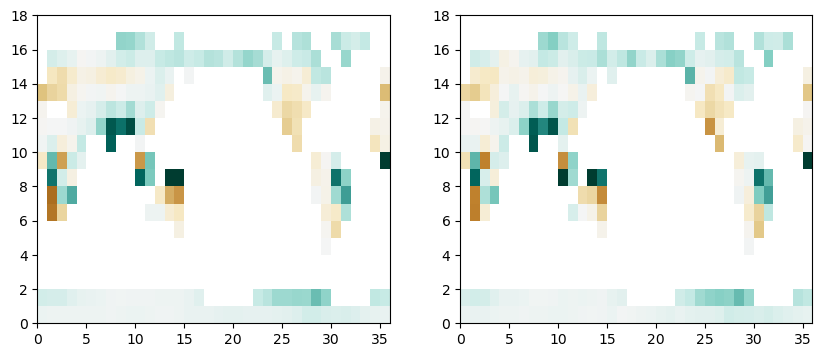

In [54]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.pcolormesh(meantrend,cmap="BrBG",vmin=-0.01,vmax=0.01)
# plt.colorbar()

plt.subplot(1,2,2)
plt.pcolormesh(mediantrend,cmap="BrBG",vmin=-0.01,vmax=0.01)
# plt.colorbar()

(array([ 1.,  3.,  7., 13.,  3.,  4.,  5.,  6.,  5.,  3.]),
 array([-0.01561939, -0.01319391, -0.01076844, -0.00834297, -0.00591749,
        -0.00349202, -0.00106654,  0.00135893,  0.0037844 ,  0.00620988,
         0.00863535]),
 <BarContainer object of 10 artists>)

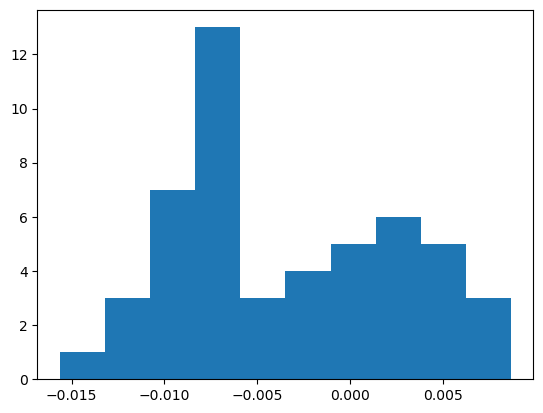

In [55]:
plt.hist(trend[:,11,25])

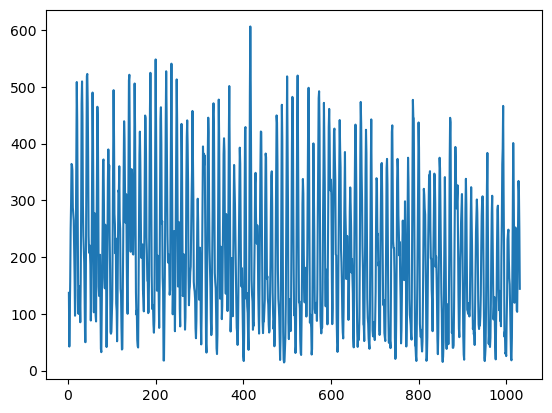

In [56]:
plt.plot(allpr[1,:,11,25])

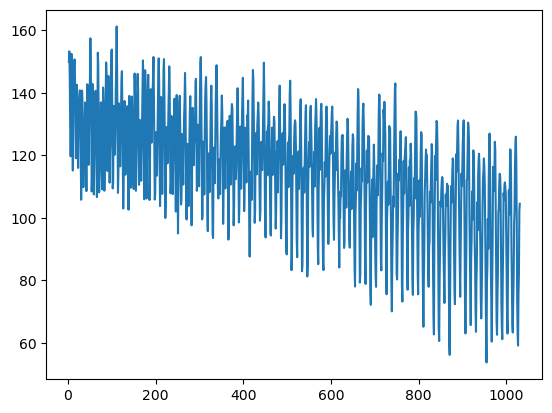

In [57]:
plt.plot(np.mean(allpr[:,:,12,25],axis=0))

In [58]:
allpr_annual = np.reshape(allpr,(50,12,86,18,36))

In [59]:
allpr_annualmean = np.nanmean(allpr_annual,axis=2)

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_76054/2333422729.py:1: RuntimeWarning: Mean of empty slice
  allpr_annualmean = np.nanmean(allpr_annual,axis=2)


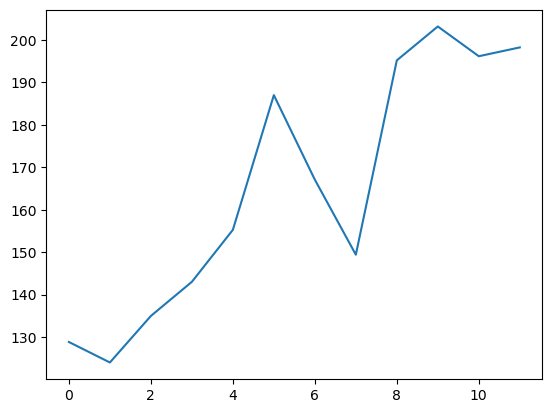

In [60]:
plt.plot(allpr_annualmean[0,:,11,7])